In [3]:
# libraries
import pandas as pd
from pathlib import Path
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import csv
from pathlib import Path
from torchmetrics.classification import BinaryJaccardIndex
import tqdm as tqdm
from typing import Dict, List
from tqdm.auto import tqdm
from going_modular.utils import save_model

/home/emilie/Documents/Fil_rouge/cirse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [10]:
class CSVDataset(Dataset):
    def __init__(self, features_path, labels_path, crop_index=4961):
        self.features_path = Path(features_path)
        self.labels_path = Path(labels_path)
        self.crop_index = crop_index

        features_files = sorted(self.features_path.glob("*.csv"))
        print(len(features_files), "feature files found.")
        labels_files = sorted(self.labels_path.glob("*.csv"))
        print(len(labels_files), "label files found.")

        self.features_dict = {f.stem: f for f in features_files}
        self.labels_dict = {f.stem: f for f in labels_files}

        self.common_keys = sorted(
            set(self.features_dict.keys()) & set(self.labels_dict.keys())
        )
        if len(self.common_keys) == 0:
            raise ValueError("No matching files found.")
        # print files that don't match
        unmatched_features = set(self.features_dict.keys()) - set(self.labels_dict.keys())
        unmatched_labels = set(self.labels_dict.keys()) - set(self.features_dict.keys())
        if unmatched_features:
            print("Warning: No label files for features:", unmatched_features)
        if unmatched_labels:
            print("Warning: No feature files for labels:", unmatched_labels)
    def __len__(self):
        return len(self.common_keys)

    def __getitem__(self, idx):
        key = self.common_keys[idx]

        # load files
        df_features = pd.read_csv(self.features_dict[key], sep=";")
        df_labels = pd.read_csv(self.labels_dict[key], sep=";")

        # remove molw column if exists
        df_features = df_features.drop(columns=["molw"], errors="ignore")
        df_labels = df_labels.drop(columns=["molw"], errors="ignore")

        # crop
        df_features = df_features.iloc[:self.crop_index]
        df_labels = df_labels.iloc[:self.crop_index]

        df_features = df_features.drop(columns=["index"], errors="ignore")
        df_labels = df_labels.drop(columns=["index"], errors="ignore")

        # convert numeric strictly
        df_features = df_features.astype("float32")
        df_labels = df_labels.astype("float32")

        # transpose to get (channels, signal_length)
        X = torch.from_numpy(df_features.to_numpy(dtype="float32").T)
        y = torch.from_numpy(df_labels.to_numpy(dtype="float32").T)

        return X, y

from torch.utils.data import DataLoader, random_split

BATCHSIZE = 8

# Dataset déjà défini
#dataset = CSVDataset(
    #"/home/emilie/Documents/Fil_rouge/Code/Rproj/mix_syntheticGAN_realnonGAN",
    #"/home/emilie/Documents/Fil_rouge/Code/Rproj/label_data"
#)

# Tailles
#train_size = int(0.8 * len(dataset))
#test_size = len(dataset) - train_size

# Split déterministe
#generator = torch.Generator().manual_seed(42)
"""train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=generator
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCHSIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCHSIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=True
)"""

'train_dataset, test_dataset = random_split(\n    dataset,\n    [train_size, test_size],\n    generator=generator\n)\n\n# DataLoaders\ntrain_loader = DataLoader(\n    train_dataset,\n    batch_size=BATCHSIZE,\n    shuffle=True,\n    drop_last=True,\n    num_workers=0,\n    pin_memory=True\n)\n\ntest_loader = DataLoader(\n    test_dataset,\n    batch_size=BATCHSIZE,\n    shuffle=False,\n    drop_last=False,\n    num_workers=0,\n    pin_memory=True\n)'

In [50]:
print(len(train_loader.dataset), len(test_loader.dataset))
print(train_loader.dataset[0][0].shape, train_loader.dataset[0][1].shape)

2516 629
torch.Size([3, 4961]) torch.Size([3, 4961])


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.plot(X_batch[0].numpy())
plt.title("Example Signal from Batch")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(y_batch[0].numpy(), cmap="viridis", cbar=True)
plt.title("Heatmap of Signal Batch")
plt.xlabel("Channel Index")
plt.ylabel("Sample Index in Batch")
plt.show()

In [ ]:
# charger fake profiles
#charger les labels

In [5]:
class down_block(nn.Module):
    def __init__(self, in_channel,out_channel,kernel, padding,stride):
        super().__init__()
        self.conv = nn.Conv1d(in_channel, out_channel, kernel_size=kernel, padding=padding, stride=stride)
        self.norm = nn.BatchNorm1d(out_channel)
        self.block = nn.Sequential(
            self.conv,
            self.norm,
            nn.LeakyReLU(0.25)
        )
    
    def forward(self, x):
        #print(x.shape)
        x = self.block(x)
        #print(x.shape)
        return x

class up_block(nn.Module):
    def __init__(self,in_channel,out_channel,kernel, padding,stride, apply_Dropout=True):
        super().__init__()
        # pre concatenation
        self.conv = nn.Conv1d(in_channel, out_channel, kernel_size=kernel, stride=1, padding=padding)
        
        # post concatenation
        self.refine = nn.Conv1d(out_channel * 2, out_channel, kernel_size=kernel, padding=padding, stride=1)
        self.norm = nn.BatchNorm1d(out_channel)
        
        #post concatenation operations
        self.post = nn.Sequential(
            self.refine, #non linearity after concatenation
            self.norm,
            nn.Dropout(0.25) if apply_Dropout else nn.Identity(),
            nn.LeakyReLU(0.25)
        )

    def forward(self, x1,skip):
        x1 = nn.functional.interpolate(x1, size=skip.shape[-1], mode="linear", align_corners=False)
        x1 = self.conv(x1)

        if x1.shape[-1] != skip.shape[-1]:
            diff = x1.shape[-1] - skip.shape[-1]
            x1 = x1[..., diff//2 : diff//2 + skip.shape[-1]] # centered cropping Ronneberger et al., 2015
        #concatenation
        #print(x1.shape)
        # print(skip.shape)
        x = torch.cat([skip, x1], dim=1)
        x = self.post(x)
        return x

class U_net(nn.Module):
    def __init__(self, in_channel, hidden_unit_list, out_channel,
                 list_kernel, apply_Dropout=True):
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        # Encoder
        encoder_channels = hidden_unit_list
        for i in range(len(encoder_channels)):
            pad = list_kernel[i] // 2
            out_ch = encoder_channels[i]

            self.downs.append(
                down_block(
                    in_channel,
                    out_ch,
                    kernel=list_kernel[i],
                    padding=pad,
                    stride=2
                )
            )
            in_channel = out_ch  # propagate channels
        # Decoder
        skip_channels = encoder_channels[:-1][::-1]
        decoder_kernels = list_kernel[:-1][::-1]

        in_ch = encoder_channels[-1]  # bottleneck

        for skip_ch, k in zip(skip_channels, decoder_kernels):
            pad = k // 2
            self.ups.append(
                up_block(
                    in_channel=in_ch,       # input from previous level
                    out_channel=skip_ch,    # enforce symmetry
                    kernel=k,
                    padding=pad,
                    stride=1,
                    apply_Dropout=apply_Dropout
                )
            )
            in_ch = skip_ch  # update for next level
        self.final = nn.Conv1d(in_ch, out_channel, kernel_size=1)

    def forward(self, x):
        skip = []  # stockage des skips pour le decoder

        #print("=== Encoder ===")
        for i, down in enumerate(self.downs):
            #print(f"Input to down[{i}]:", x.shape)
            x = down(x)
            #print(f"Output from down[{i}]:", x.shape)
            skip.append(x)

        #print("Encoder done. Bottleneck:", x.shape)
        #print("Skip list sizes before removing bottleneck:", [s.shape for s in skip])

        # On enlève le bottleneck des skips
        skip = skip[:-1]
        skip = skip[::-1]  # pour correspondre à l’ordre des up_blocks
        #print("Skip list after removing bottleneck and reversing:", [s.shape for s in skip])

        #print("=== Decoder ===")
        for i, up in enumerate(self.ups):
            #print(f"\n--- Up block {i} ---")
            #print("x1 (input to up block, BEFORE interpolate):", x.shape)
            #print("x2 (skip connection):", skip[i].shape)
            x = up(x, skip[i])
            
            #print("After up_processing:", x.shape)

        # Final upsample pour s'assurer que la sortie = input
        x = nn.functional.interpolate(x, size=4961, mode="linear", align_corners=False)
        x = self.final(x) #self.final(x).squeeze(1)
        #print("\nFinal output:", x.shape)

        return x # output : [10, 4961]

In [ ]:
# other model
# https://www.nature.com/articles/s41598-020-64655-4

In [ ]:
#!pip install torchmetrics

In [ ]:
#Metrics 
# https://arxiv.org/pdf/2101.01666
# https://arxiv.org/pdf/1505.04597

In [5]:
from pathlib import Path
net = U_net(
    in_channel=3,
    hidden_unit_list=[16,16,32,32,64,64],
    out_channel=3,
    list_kernel=[9,9,6,6,3,3],
    apply_Dropout=True
)
# 1. Create models directory 
MODEL_PATH = Path("../Models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 
MODEL_NAME = f"pytorch_workflow_unet.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=net.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: ../Models/pytorch_workflow_unet.pth


In [6]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn,
               metric,
               optimizer,
               device):
    
    model.train()
    metric.reset()
    full_loss, counts = 0, 0
    
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        # y_batch = torch.stack(y_batch).float()
        logits = model(x_batch)

        optimizer.zero_grad()
        loss = loss_fn(logits, y_batch.float())
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).int()
        
        # Metrics
        full_loss += loss.item() * x_batch.size(0)
        # size issues?
        metric.update(preds, y_batch.int()) #preds.squeeze(1)
        counts += x_batch.size(0)
    score = metric.compute()
    metric.reset()
    return full_loss, score, counts
    

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn,
              metric,
              device):
    model.eval()
    metric.reset()
    with torch.no_grad():
                full_loss, counts = 0, 0
                for x_test,y_test in dataloader:
                    
                    # print(x_test.shape)
                    # print(x_test.size(0))
                    
                    x_test,y_test = x_test.to(device), y_test.to(device)
                    # y_test = torch.stack(y_test).float()
                    y_logits = model(x_test)
                    probs = torch.sigmoid(y_logits)
                    preds = (probs > 0.5).int()
                    loss = loss_fn(y_logits, y_test.float())
                    full_loss += loss.item() * x_test.size(0)
                    metric.update(preds, y_test.int()) #preds.squeeze(1) y_test.int().squeeze(1)
                    counts += x_test.size(0)
    score = metric.compute()
    metric.reset()
    return full_loss, score, counts

In [7]:
def train_test(model: torch.nn.Module, 
          train_loader: torch.utils.data.DataLoader, 
          test_loader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
               metric,
          epochs: int,
          device: torch.device):
    # device
    model.to(device)

    # Save model
    # 1. Create models directory 
    MODEL_PATH = Path("../Models")
    MODEL_PATH.mkdir(parents=True, exist_ok=True)

    for epoch in tqdm(range(epochs)):
        #print(f"[INFO] Model: {model}")
        #print(f"[INFO] DataLoader: {dataloader_name}")
        print(f"[INFO] Number of epochs: {epochs}")

        # Training loop
        train_loss, train_score, train_counts = train_step(model=model,
                                            dataloader=train_loader,
                                            loss_fn=loss_fn,
                                            metric=metric,
                                            optimizer=optimizer,
                                            device=device)
        print(f"[INFO] train loss: {train_loss}")
        print(f"[INFO] train metrics: {train_score}")
        print(f"[INFO] train counts: {train_counts}")

        if epoch % 1 == 0:
            #Test loop
            test_loss, test_score, test_counts = test_step(model=model,
                                            dataloader=test_loader,
                                            loss_fn=loss_fn,
                                            metric=metric,
                                            device=device)
            print(f"[INFO] test loss: {test_loss}")
            print(f"[INFO] test metrics: {test_score}")
            print(f"[INFO] test counts: {test_counts}")
        if epoch % 5 == 0:
            # 2. Create model save path 
            MODEL_NAME = f"{epoch}_pytorch_workflow_unet.pth"
            MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

            # 3. Save the model state dict 
            print(f"Saving model to: {MODEL_SAVE_PATH}")
            torch.save(obj=net.state_dict(), # only saving the state_dict() only saves the models learned parameters
                    f=MODEL_SAVE_PATH)

In [ ]:
net = U_net(
    in_channel=3,
    hidden_unit_list=[16,16,32,32,64,64],
    out_channel=3,
    list_kernel=[9,9,6,6,3,3],
    apply_Dropout=True
)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(net.parameters(), lr=1e-3)

# Metrics
metric = BinaryJaccardIndex().to(device)
epochs = 50

train_test(model=net, 
          train_loader=train_loader, 
          test_loader=test_loader, 
          optimizer=optimizer,
          loss_fn=loss_fn,
               metric=metric,
          epochs=epochs,
          device=device)

In [60]:
# test models once trained

#load model
model = U_net(
    in_channel=3,
    hidden_unit_list=[16,16,32,32,64,64],
    out_channel=3,
    list_kernel=[9,9,6,6,3,3],
    apply_Dropout=True
)
model.load_state_dict(torch.load("Models/syntheticGAN+real/45_pytorch_workflow_unet.pth"))
model.to(device)
model.eval()

# load test data
test_feature_path = "Data/Test/Test/pre_processed"
test_label_path = "Data/Test/Test/labels"
test_dataset = CSVDataset(test_feature_path, test_label_path)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCHSIZE,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=True)
loss_fn = nn.BCEWithLogitsLoss()

# test on test set (real data never seen during training)
with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test, y_test = x_test.to(device), y_test.to(device)
        y_logits = model(x_test)
        probs = torch.sigmoid(y_logits)
        preds = (probs > 0.5).int()
        print("Preds shape:", preds.shape)
        print("Y_test shape:", y_test.shape)
        # metrics
        loss = loss_fn(y_logits, y_test.float())
        print(f"Test loss: {loss.item()}")
        metrics = BinaryJaccardIndex().to(device)
        metrics.update(preds, y_test.int())
        score = metrics.compute()
        print(f"Test Jaccard Index: {score.item()}")

        #save predictions and labels for later analysis
        #torch.save(preds.cpu(), "/home/emilie/Documents/Fil_rouge/Data/Test/Test/Predictions/synthetic_nonGAN/test_preds.pth")
        #torch.save(y_test.cpu(), "/home/emilie/Documents/Fil_rouge/Data/Test/Test/Predictions/synthetic_nonGAN/test_labels.pth")
        break


192 feature files found.
192 label files found.
Preds shape: torch.Size([8, 3, 4961])
Y_test shape: torch.Size([8, 3, 4961])
Test loss: 0.018406802788376808
Test Jaccard Index: 0.8626560568809509


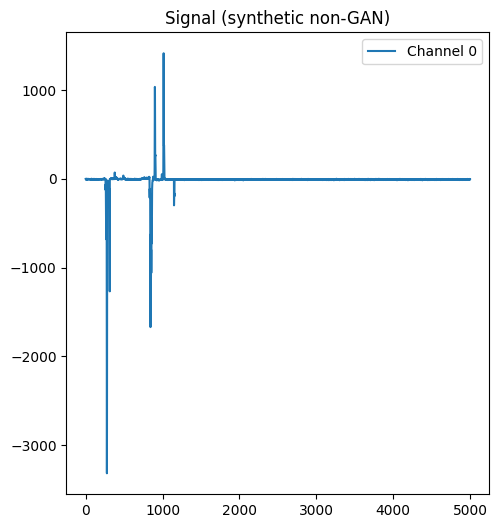

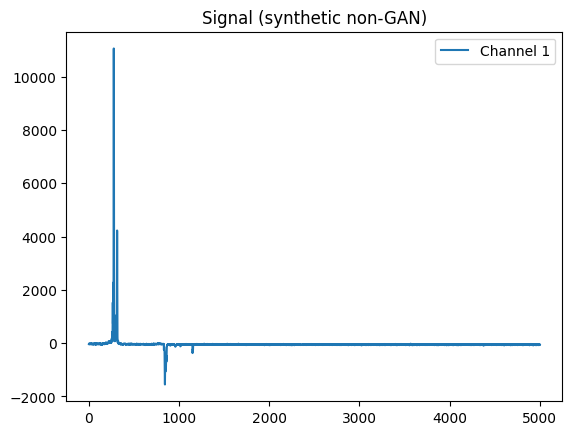

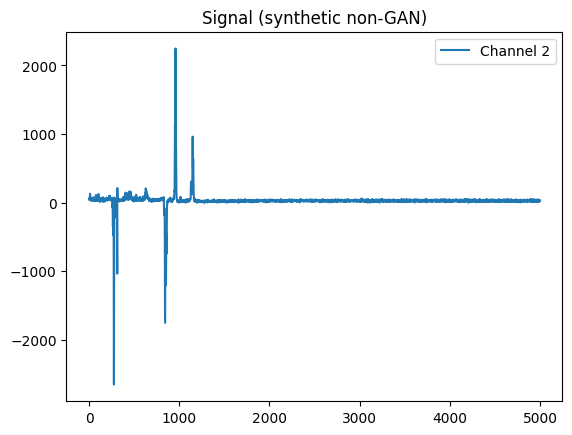

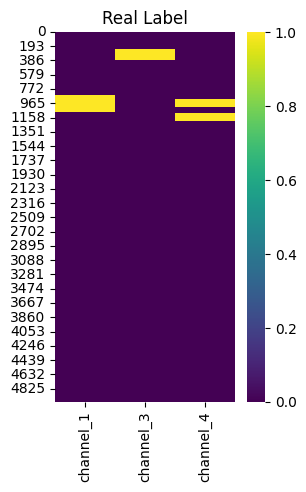

'for model_name, model_path in models.items():\n    model.load_state_dict(torch.load(model_path))\n    model.to(device)\n    model.eval()\n\n    signal_tensor = torch.from_numpy(signal.to_numpy(dtype="float32").T).unsqueeze(0).to(device) # add batch dimension\n    model \n    with torch.no_grad():\n        y_logits = model(signal_tensor)\n        probs = torch.sigmoid(y_logits)\n        preds = (probs > 0.5).int().squeeze(0) # remove batch dimension\n\n        plt.figure(figsize=(4, 8))\n        preds = preds.cpu().numpy().T\n        sns.heatmap(preds, cmap="viridis", cbar=True)\n        plt.title(f"Predictions for model {model_name}")\n        plt.show()'

In [22]:
# plot results for each model
import matplotlib.pyplot as plt
import seaborn as sns
# test on one sample from test set
model = U_net(
    in_channel=3,
    hidden_unit_list=[16,16,32,32,64,64],
    out_channel=3,
    list_kernel=[9,9,6,6,3,3],
    apply_Dropout=True
)
# for each model, load state dict and test on one sample from test set
models = {
    "synthetic_nonGAN": "/home/emilie/Documents/Fil_rouge/Models/synthetic_nonGAN/45_pytorch_workflow_unet.pth",
    "synthetic_GAN": "/home/emilie/Documents/Fil_rouge/Models/synthetic_GAN/45_pytorch_workflow_unet.pth",
    "synthetic+real_nonGAN": "/home/emilie/Documents/Fil_rouge/Models/synthetic+real_nonGAN/45_pytorch_workflow_unet.pth",
    "syntheticGAN+real": "/home/emilie/Documents/Fil_rouge/Models/syntheticGAN+real/45_pytorch_workflow_unet.pth"
}
test_feature = "/home/emilie/Documents/Fil_rouge/Data/Test/Test/pre_processed"
signal = pd.read_csv(f"{test_feature}/M1_pl10009.csv", sep=";")
signal = signal.drop(columns=["index", "molw"], errors="ignore")
real_label = pd.read_csv("/home/emilie/Documents/Fil_rouge/Data/Test/Test/labels/M1_pl10009.csv", sep=";")
real_label = real_label.drop(columns=["index", "molw"], errors="ignore")
# rename columns to channel names in real_label
real_label.columns = signal.columns

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
# plot each signal channel separately
for i in range(signal.shape[1]):
    plt.plot(signal.iloc[:, i], label=f"Channel {i}")
    plt.title("Signal (synthetic non-GAN)")
    plt.legend()
    plt.show()

#plot real label
plt.subplot(1, 2, 2)
sns.heatmap(real_label, cmap="viridis", cbar=True)
plt.title("Real Label")
plt.show()

"""for model_name, model_path in models.items():
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    model.eval()

    signal_tensor = torch.from_numpy(signal.to_numpy(dtype="float32").T).unsqueeze(0).to(device) # add batch dimension
    model 
    with torch.no_grad():
        y_logits = model(signal_tensor)
        probs = torch.sigmoid(y_logits)
        preds = (probs > 0.5).int().squeeze(0) # remove batch dimension

        plt.figure(figsize=(4, 8))
        preds = preds.cpu().numpy().T
        sns.heatmap(preds, cmap="viridis", cbar=True)
        plt.title(f"Predictions for model {model_name}")
        plt.show()"""

(4961, 3)
(4961,)


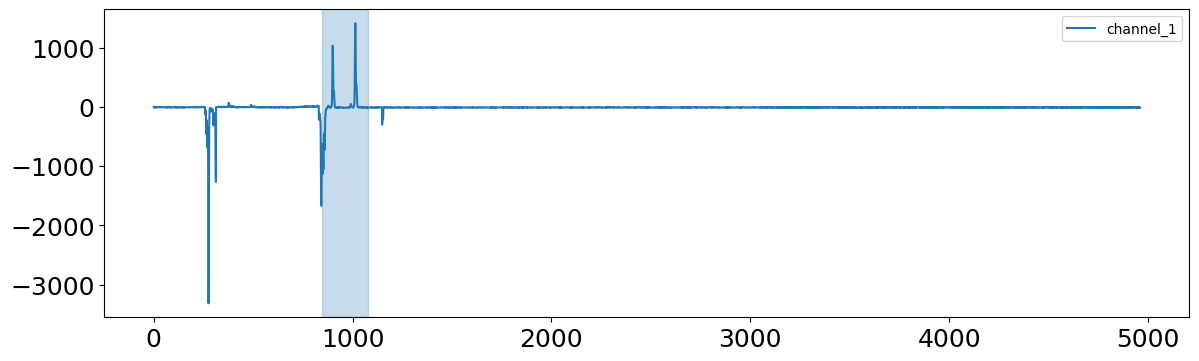

(4961,)


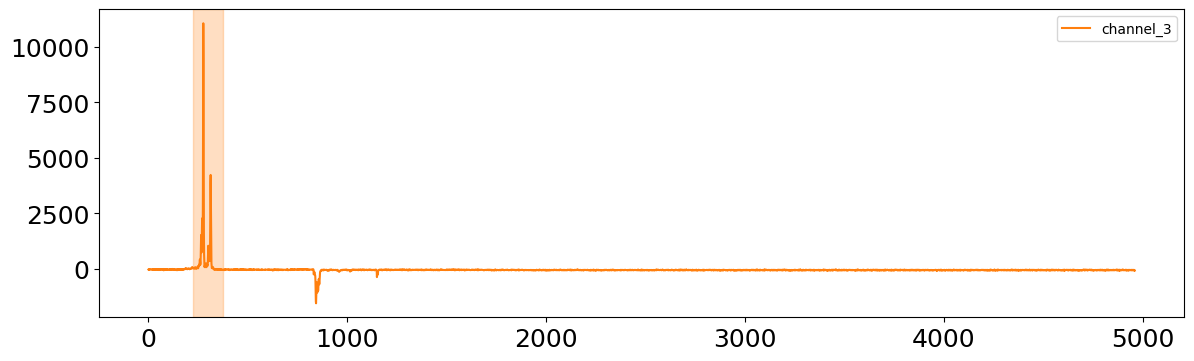

(4961,)


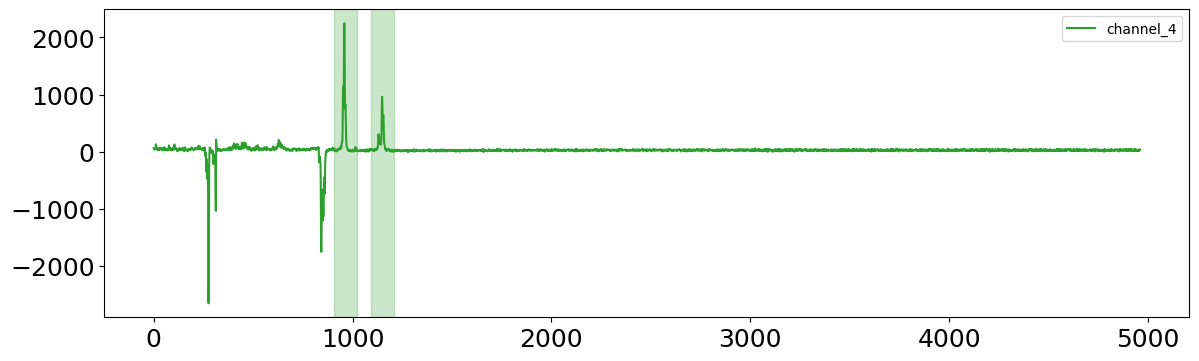

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load data ---
test_feature = "/home/emilie/Documents/Fil_rouge/Data/Test/Test/pre_processed"
signal = pd.read_csv(f"{test_feature}/M1_pl10009.csv", sep=";")
signal = signal.drop(columns=["index", "molw"], errors="ignore")
# crop to 4961 samples
signal = signal.iloc[:4961,:]
print(signal.shape)
real_label = pd.read_csv(
    "/home/emilie/Documents/Fil_rouge/Data/Test/Test/labels/M1_pl10009.csv",
    sep=";")

real_label = real_label.drop(columns=["index", "molw"], errors="ignore")
#crop to 4961 samples
real_label = real_label.iloc[:4961,:]
real_label.columns = signal.columns

# --- Plot one figure per channel ---
colors = plt.cm.tab10.colors

for i, col in enumerate(signal.columns):

    fig, ax = plt.subplots(figsize=(14, 4))

    # Plot signal
    print(signal[col].shape)
    ax.plot(signal[col], 
            color=colors[i % len(colors)], 
            label=f"{col}")

    # Detect peak regions (label == 1)
    label_array = real_label[col].values
    in_peak = False
    start = 0
    peak_regions = []

    for j, val in enumerate(label_array):
        if val == 1 and not in_peak:
            in_peak = True
            start = j
        elif val == 0 and in_peak:
            in_peak = False
            peak_regions.append((start, j))

    if in_peak:
        peak_regions.append((start, len(label_array)))

    # Add colored boxes
    for (start, end) in peak_regions:
        ax.axvspan(start, end,
                   color=colors[i % len(colors)],
                   alpha=0.25)
    # Taille des graduations (valeurs numériques)
    ax.tick_params(axis='both', labelsize=18)
    # (optionnel) taille du titre
    ax.legend()
    plt.show()

In [56]:
import re
import csv

# Paths
# synthetic_GAN
# synthetic+real_GAN
# synthetic+real_nonGAN
# synthetic_nonGAN

input_log = "/home/emilie/Documents/Fil_rouge/Models/synthetic+real_GAN/results"
output_csv = "/home/emilie/Documents/Fil_rouge/Models/syntheticGAN+real/training_metrics.csv"

# Regex patterns
train_loss_pattern = re.compile(r"\[INFO\] train loss:\s*([0-9.eE+-]+)")
train_metric_pattern = re.compile(r"\[INFO\] train metrics:\s*([0-9.eE+-]+)")
test_loss_pattern = re.compile(r"\[INFO\] test loss:\s*([0-9.eE+-]+)")
test_metric_pattern = re.compile(r"\[INFO\] test metrics:\s*([0-9.eE+-]+)")

rows = []
epoch = 0

with open(input_log, "r") as f:
    lines = f.readlines()

i = 0
while i < len(lines):
    line = lines[i]

    if "[INFO] train loss:" in line:
        epoch += 1
        
        train_loss = float(train_loss_pattern.search(line).group(1))
        train_metric = float(train_metric_pattern.search(lines[i+1]).group(1))
        
        # test values may appear a few lines later
        test_loss = None
        test_metric = None
        
        for j in range(i, min(i+10, len(lines))):
            if test_loss is None and test_loss_pattern.search(lines[j]):
                test_loss = float(test_loss_pattern.search(lines[j]).group(1))
            if test_metric is None and test_metric_pattern.search(lines[j]):
                test_metric = float(test_metric_pattern.search(lines[j]).group(1))
        
        rows.append([epoch, train_loss, train_metric, test_loss, test_metric])
    
    i += 1

# Write CSV
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "train_metrics", "test_loss", "test_metrics"])
    writer.writerows(rows)

print(f"Saved to {output_csv}")

Saved to /home/emilie/Documents/Fil_rouge/Models/syntheticGAN+real/training_metrics.csv


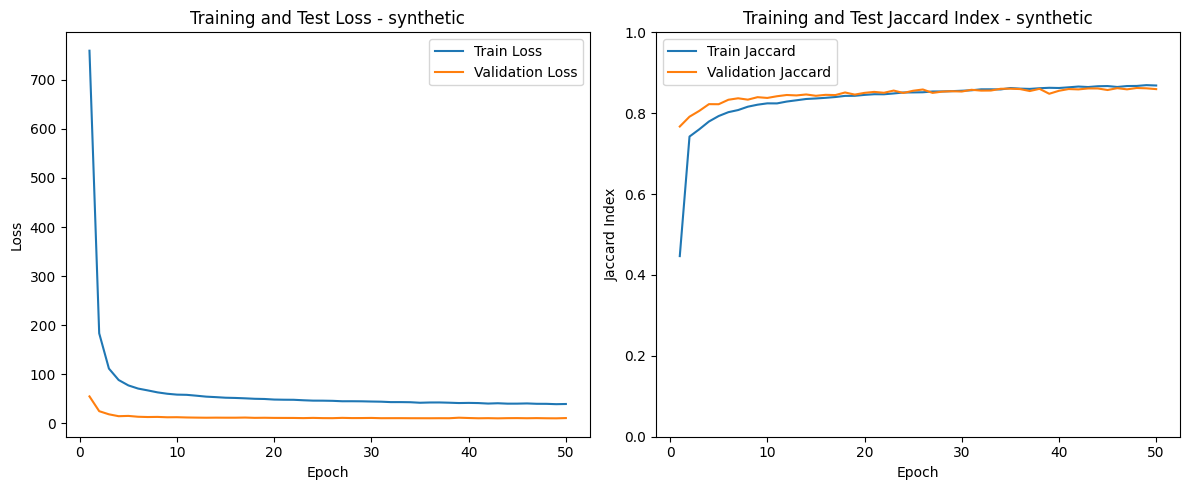

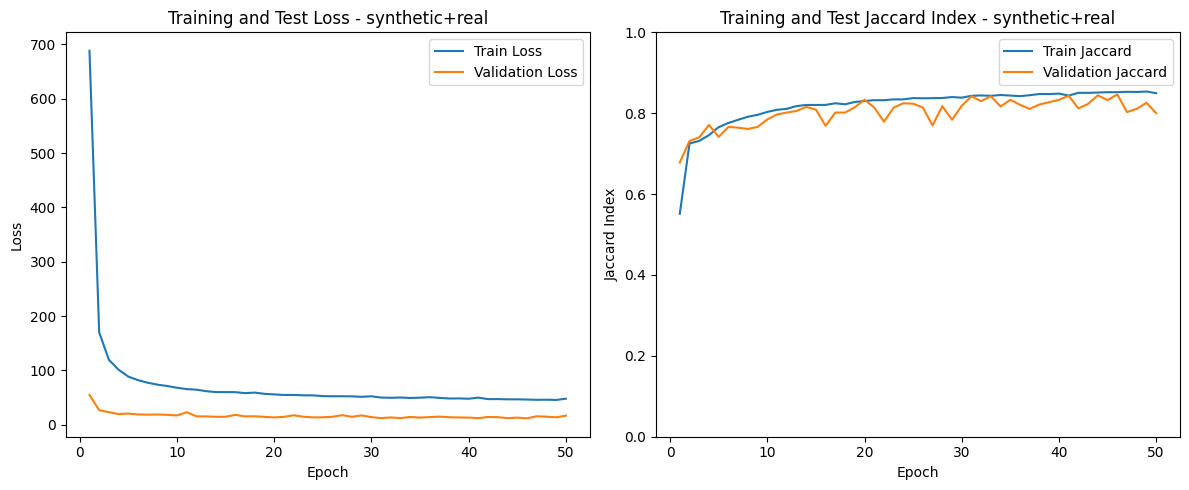

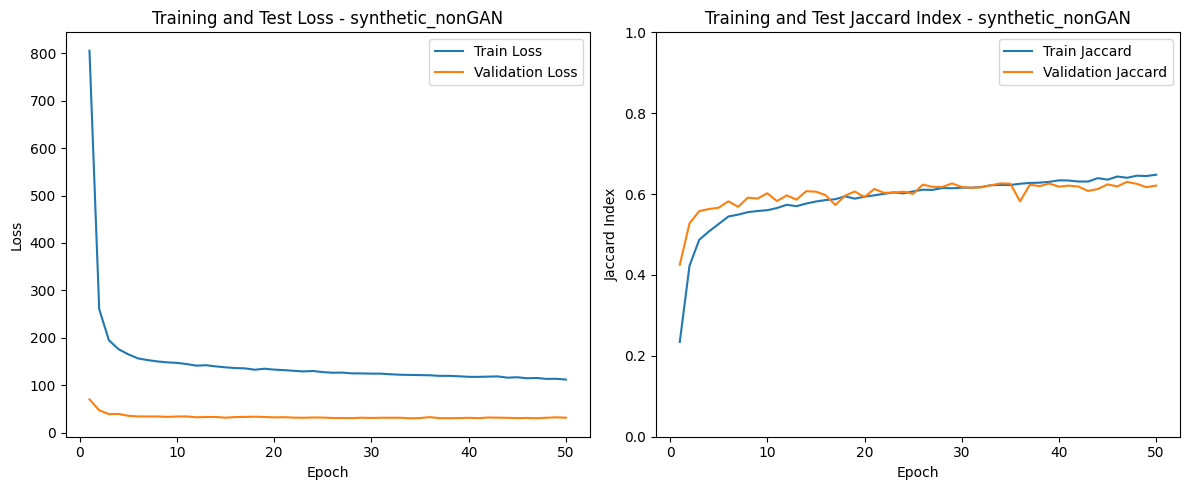

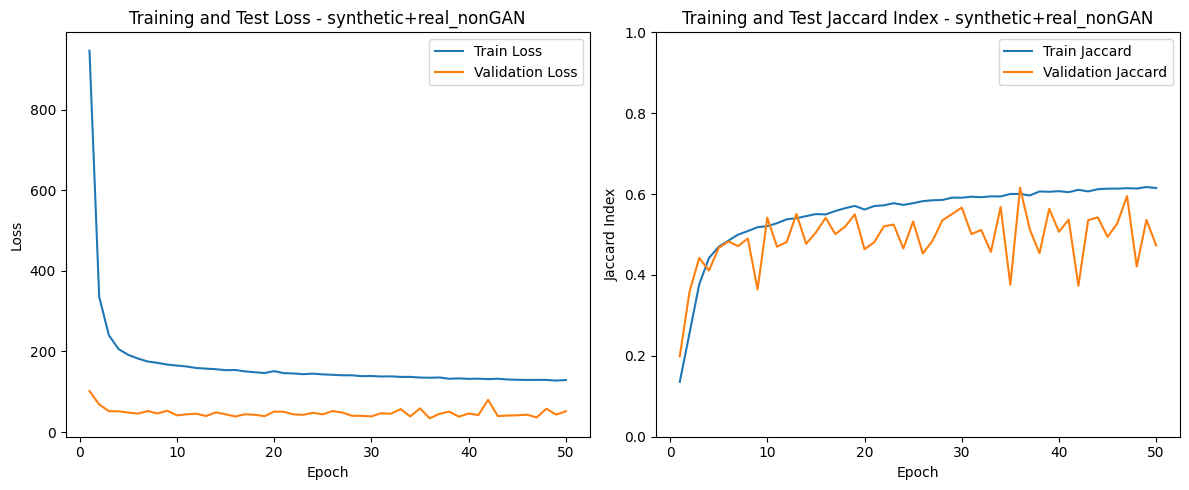

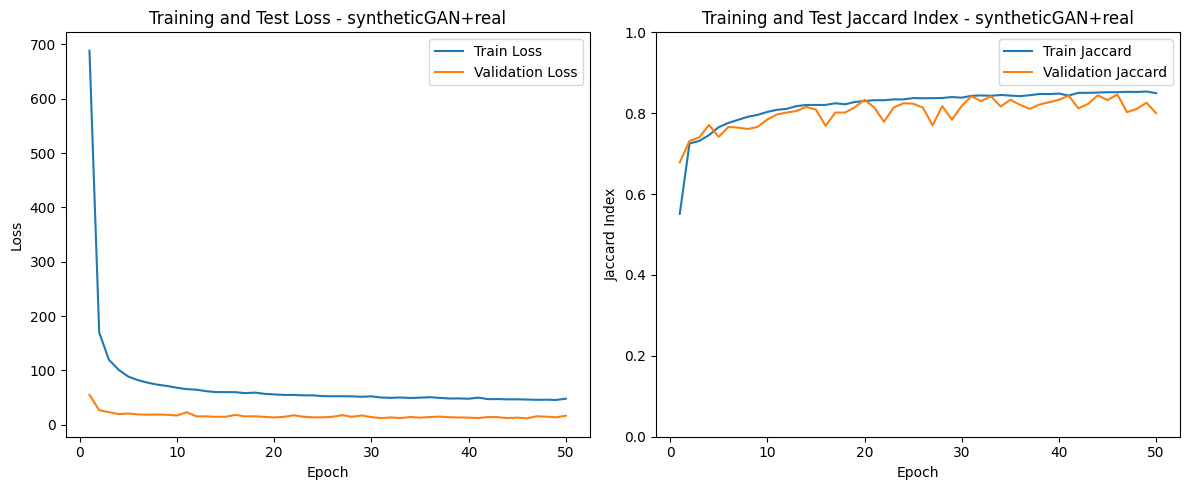

In [58]:
# plot training curves
import pandas as pd
import matplotlib.pyplot as plt
# loop over the 4 files
files = {
    "synthetic": "/home/emilie/Documents/Fil_rouge/Models/synthetic_GAN/training_metrics.csv",
    "synthetic+real": "/home/emilie/Documents/Fil_rouge/Models/synthetic+real_GAN/training_metrics.csv",
    "synthetic_nonGAN": "/home/emilie/Documents/Fil_rouge/Models/synthetic_nonGAN/training_metrics.csv",
    "synthetic+real_nonGAN": "/home/emilie/Documents/Fil_rouge/Models/synthetic+real_nonGAN/training_metrics.csv",
    "syntheticGAN+real": "/home/emilie/Documents/Fil_rouge/Models/syntheticGAN+real/training_metrics.csv"
}

filenames = ["synthetic", "synthetic+real", "synthetic_nonGAN", "synthetic+real_nonGAN", "syntheticGAN+real"]
for name in filenames:
    df = pd.read_csv(files[name])
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
    plt.plot(df["epoch"], df["test_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Test Loss - {name}")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(df["epoch"], df["train_metrics"], label="Train Jaccard")
    plt.plot(df["epoch"], df["test_metrics"], label="Validation Jaccard")
    plt.xlabel("Epoch")
    plt.ylim(0, 1)
    plt.ylabel("Jaccard Index")
    plt.title(f"Training and Test Jaccard Index - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()